<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
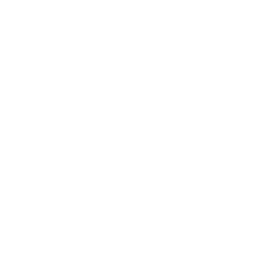
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Kundekreditprofilering via kanonisk diskrimination</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Finansielle tjenester / kreditrisikoanalyse &nbsp;|&nbsp; Marts 2026</p>
</div>
</div>
</div>

## Resumé

Tre lånestatusgrupper i en forbrugerrealkreditportefølje — **misligholdt**, **løbende** og **førtidsindfriet** — adskiller sig langs flere finansielle sundhedsdimensioner på én gang, hvilket gør ethvert enkelt nøgletal til et svagt risikosignal. Denne notebook anvender **PROC CANDISC** (kanonisk diskriminantanalyse) på en risikogennemgangsstikprøve med 100 kunder og kondenserer seks korrelerede finansielle nøgletal til to kanoniske dimensioner, der maksimerer adskillelsen mellem de tre statusgrupper.

Den første kanoniske dimension bærer næsten hele adskillelsen mellem grupperne — kanonisk korrelation **0.958**, der deler **91.8%** af sin varians med gruppetilhørsforhold — og ordner låntagere rent fra misligholdt i den ene yderkant til førtidsindfriet i den anden. Den anden dimension (kanonisk korrelation **0.503**, kvadreret **0.254**) tilføjer en sekundær kontrast anført af restancehistorik og gearing. Kvadrerede Mahalanobis-afstande bekræfter, at **DEFAULT**- og **PREPAID**-centroiderne er det mest adskilte par (**75.3**), med **CURRENT** placeret mellem dem (34.3 fra DEFAULT, 10.1 fra PREPAID). De resulterende kanoniske scorer danner et kompakt sammensat risikoindeks, der er velegnet til porteføljesegmentering og scorekortkalibrering.

## Datakilder

| Kilde | Beskrivelse | Poster |
|--------|-------------|--------|
| WORK.LOAN_PROFILES | Syntetiske finansielle nøgletal og adfærdsmål for kunder, mærket efter lånestatus, trukket som en balanceret risikogennemgangsstikprøve | 100 |

Stikprøven overrepræsenterer bevidst misligholdte og førtidsindfriede konti (et case-kontrol-lignende træk), så hver statusgruppe er stor nok til at estimere en stabil kovariansstruktur inden for gruppen til diskriminantanalysen.

---

In [1]:
/* --------------------------------------------------------
   Generate a synthetic loan-customer risk-review sample.
   Three status groups (DEFAULT / CURRENT / PREPAID) are
   over-sampled toward the risk tails so each class is large
   enough for a stable within-group covariance estimate.
   -------------------------------------------------------- */
data work.loan_profiles;
    CALL streaminit(42);
    LÆNGDE loan_status $10 vintage $7 customer_id $12;
    TABEL statuses[3] $10 _temporary_ ('DEFAULT' 'CURRENT' 'PREPAID');
    TABEL vintages[4] $7 _temporary_ ('2022-Q1' '2022-Q3' '2023-Q1' '2023-Q3');
    GØR i = 1 TIL 20000;
        customer_id = cat('CUST-', SKRIV_V(i, z6.));
        vintage = vintages[int(rand('uniform') * 4) + 1];
        status_prob = rand('uniform');
        HVIS status_prob < 0.30 SÅ status_idx = 1;       /* DEFAULT */
        ELLERS HVIS status_prob < 0.70 SÅ status_idx = 2;  /* CURRENT */
        ELLERS status_idx = 3;                             /* PREPAID */
        loan_status = statuses[status_idx];
        /* Financial ratios separate the three status groups */
        HVIS loan_status = 'DEFAULT' SÅ GØR;
            dti_ratio          = rand('normal', 0.58, 0.12);
            ltv_ratio          = rand('normal', 0.92, 0.10);
            payment_to_income  = rand('normal', 0.42, 0.08);
            credit_utilization = rand('normal', 0.85, 0.10);
            months_delinquent  = int(rand('exponential') * 4) + 1;
            savings_balance    = rand('exponential') * 4000 + 200;
        SLUT;
        ELLERS HVIS loan_status = 'CURRENT' SÅ GØR;
            dti_ratio          = rand('normal', 0.35, 0.10);
            ltv_ratio          = rand('normal', 0.78, 0.09);
            payment_to_income  = rand('normal', 0.28, 0.07);
            credit_utilization = rand('normal', 0.45, 0.15);
            months_delinquent  = 0;
            savings_balance    = rand('exponential') * 8000 + 200;
        SLUT;
        ELLERS GØR;
            dti_ratio          = rand('normal', 0.22, 0.07);
            ltv_ratio          = rand('normal', 0.60, 0.12);
            payment_to_income  = rand('normal', 0.20, 0.05);
            credit_utilization = rand('normal', 0.25, 0.12);
            months_delinquent  = 0;
            savings_balance    = rand('exponential') * 16000 + 500;
        SLUT;
        /* Round and constrain ratios to valid ranges */
        dti_ratio          = round(dti_ratio, 0.001);
        ltv_ratio          = round(ltv_ratio, 0.001);
        payment_to_income  = round(payment_to_income, 0.001);
        credit_utilization = round(credit_utilization, 0.001);
        savings_balance    = round(savings_balance, 0.01);
        HVIS dti_ratio < 0.05 SÅ dti_ratio = 0.05;
        HVIS dti_ratio > 0.99 SÅ dti_ratio = 0.99;
        HVIS ltv_ratio < 0.10 SÅ ltv_ratio = 0.10;
        HVIS ltv_ratio > 1.20 SÅ ltv_ratio = 1.20;
        HVIS credit_utilization < 0.01 SÅ credit_utilization = 0.01;
        HVIS credit_utilization > 0.99 SÅ credit_utilization = 0.99;
        UDDATA;
    SLUT;
    FJERN i status_prob status_idx;
KØR;


NOTE: DATA work.loan_profiles

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.loan_profiles (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  7.31 seconds
  cpu   7.31 seconds


---

### Baseline-gruppeprofiler

Før kondenseringen af nøgletallene opsummeres, hvordan de tre statusgrupper adskiller sig én variabel ad gangen, og sammensætningen af stikprøven på tværs af oprindelsesårgange bekræftes.

                                                  The MEANS Procedure

                                    Analysis Variable : dti_ratio Gæld-til-indkomst

        Lånestatus           N Obs           Mean        Std Dev
        --------------------------------------------------------
        CURRENT                 46          0.331          0.112
        DEFAULT                 29          0.570          0.114
        PREPAID                 25          0.216          0.056
        --------------------------------------------------------

                                       Analysis Variable : ltv_ratio LTV-forhold

        Lånestatus           N Obs           Mean        Std Dev
        --------------------------------------------------------
        CURRENT                 46          0.776          0.080
        DEFAULT                 29          0.914          0.103
        PREPAID                 25          0.585          0.104
        --------------------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_vintage_loan_status.spec.json
NOTE: PROC FREQ statement used.


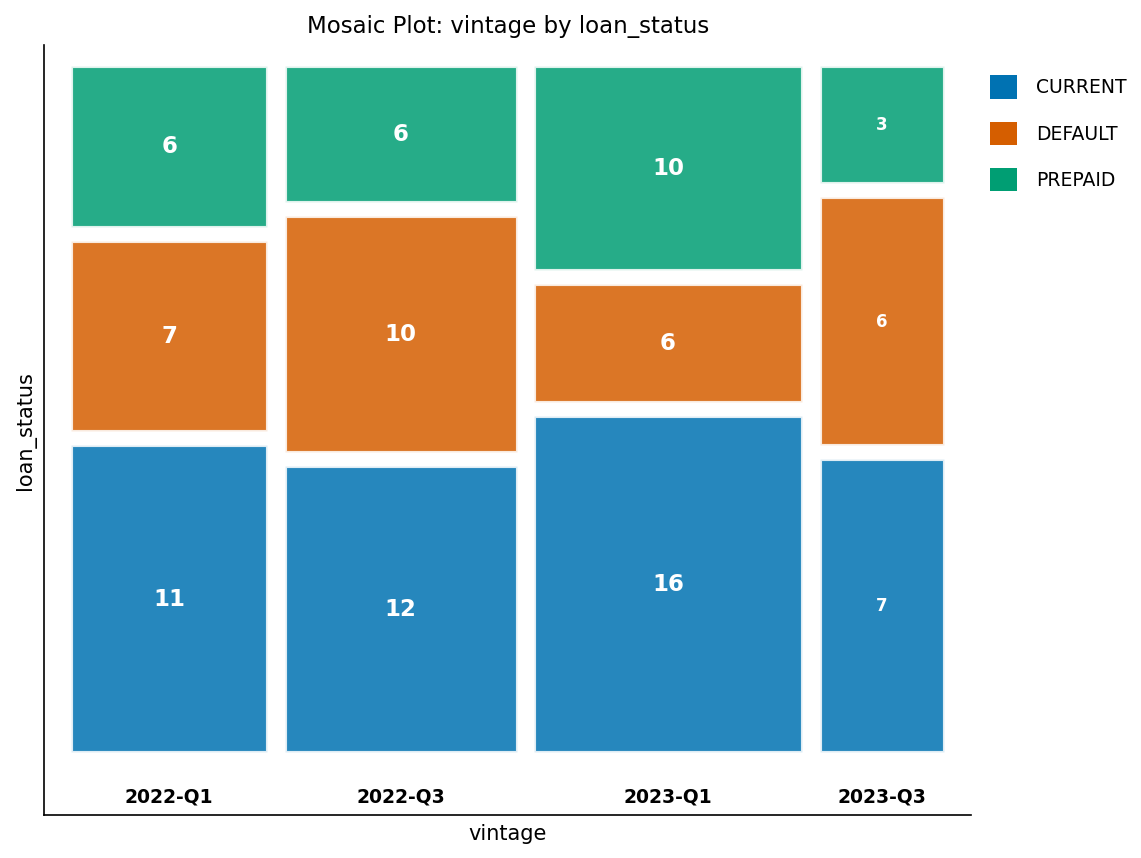

In [2]:
/* --------------------------------------------------------
   Baseline financial-ratio distributions by loan status
   -------------------------------------------------------- */
PROCEDURE GENNEMSNIT data=work.loan_profiles n mean std maxdec=3;
    KLASSE loan_status;
    VARIABEL dti_ratio ltv_ratio payment_to_income credit_utilization
        savings_balance months_delinquent;
    MÆRKAT loan_status='Lånestatus' dti_ratio='Gæld-til-indkomst' ltv_ratio='LTV-forhold'
           payment_to_income='Betaling-til-indkomst' credit_utilization='Kreditudnyttelse'
           savings_balance='Opsparingssaldo' months_delinquent='Måneder i restance';
KØR;

/* --------------------------------------------------------
   Sample composition by vintage and status
   -------------------------------------------------------- */
PROCEDURE FREKVENSER data=work.loan_profiles;
    TABLES vintage * loan_status / nocum nopercent;
    MÆRKAT vintage='Årgang' loan_status='Lånestatus';
KØR;

---

### Kanonisk diskriminantanalyse

Tilpas én samlet kanonisk diskriminantmodel på tværs af alle 100 kunder. `OUT=` skriver de kanoniske scorer pr. kunde, `OUTSTAT=` opfanger den kanoniske struktur, klassecentroiderne og de kvadrerede Mahalanobis-afstande, og `DISTANCE` anmoder om afstandene mellem grupperne. Den annoncerede procedure her er præcis den, der kører: **PROC CANDISC**.


NOTE: ODS OUTPUT: CANONICALCORRELATIONS -> can_corr
NOTE: PROC CANDISC data=work.loan_profiles ncan=Some(2) prefix=Can

NOTE: Using Python/scikit-learn for canonical discriminant analysis
NOTE: Number of Observations: 100
NOTE: Number of Classes: 3
NOTE: Class Level Information:
NOTE:   CURRENT: 46
NOTE:   DEFAULT: 29
NOTE:   PREPAID: 25
NOTE: Canonical Correlations:
NOTE:   Can1: 0.958136
NOTE:   Can2: 0.503509
NOTE: Eigenvalues of Inv(E)*H:
NOTE:                          Canonical  Approximate  Squared
NOTE:               Eigenvalue Correlation  Std Error Correlation
NOTE:   Can1       11.198645    0.958136            0.918024
NOTE:   Can2        0.339624    0.503509            0.253522
NOTE: Multivariate Statistics and F Approximations:
NOTE:   Statistic                Value     F Value  Num DF  Den DF  Pr > F
NOTE:   Wilks' Lambda         0.061194     46.65      12   184.0   0.0000
NOTE:   Pillai's Trace        1.171545     21.68      12   184.0   0.0000
NOTE:   Hotelling-Lawley  

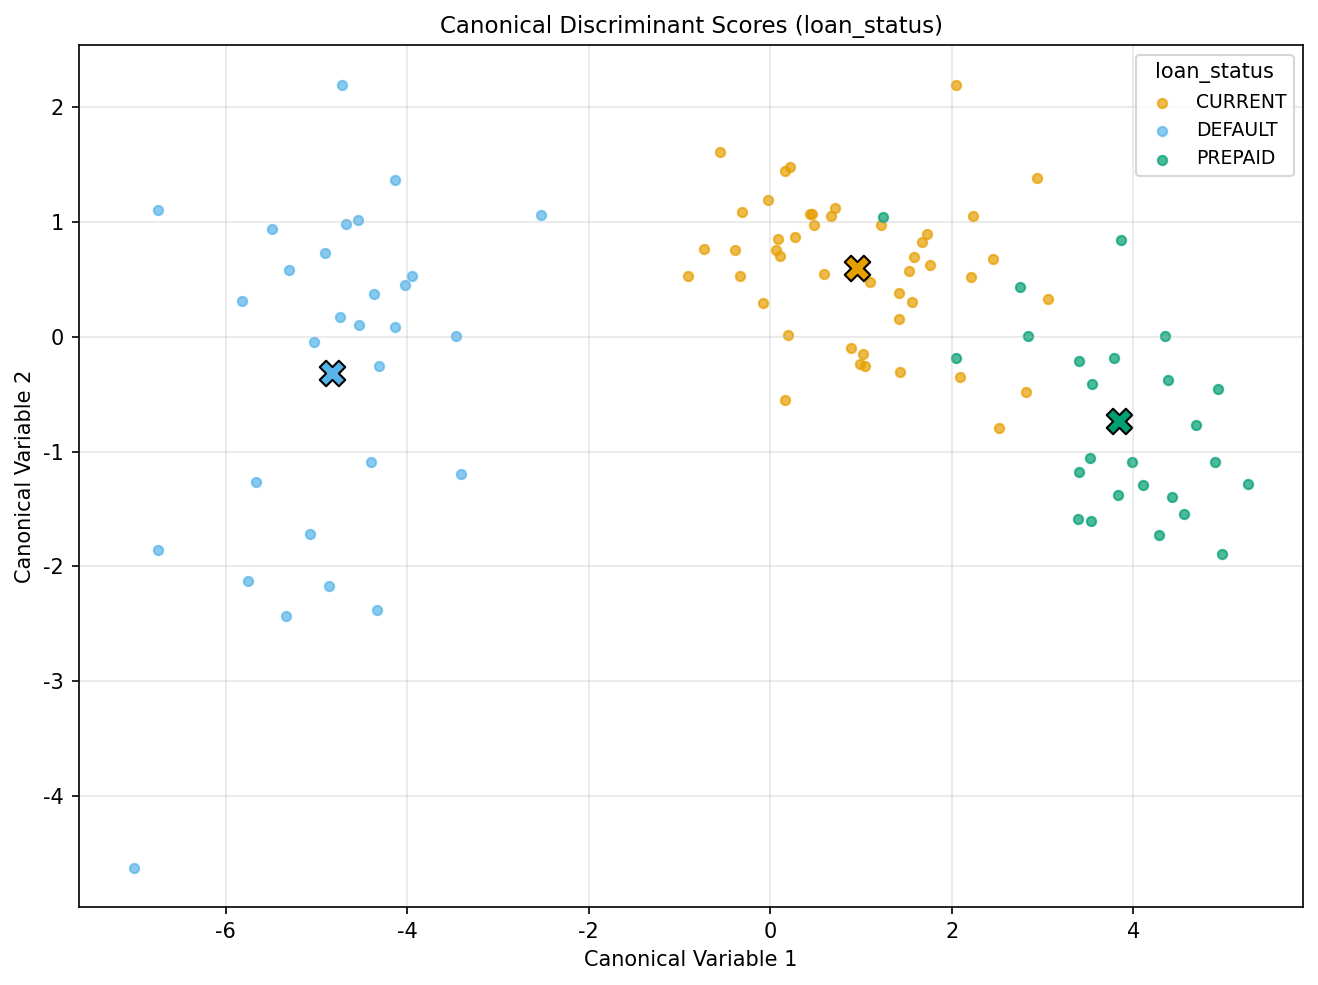

In [3]:
/* --------------------------------------------------------
   Canonical discriminant analysis of loan-status groups.
   OUT=    per-customer canonical scores (Can1, Can2)
   OUTSTAT= structure, class means, Mahalanobis distances
   -------------------------------------------------------- */
ODS UDDATA CanonicalCorrelations=work.can_corr;

PROCEDURE CANDISC data=work.loan_profiles
    out=work.risk_scores
    OUTSTAT=work.can_stat
    ncan=2
    distance;
    KLASSE loan_status;
    VARIABEL dti_ratio ltv_ratio payment_to_income credit_utilization
        savings_balance months_delinquent;
    MÆRKAT loan_status='Lånestatus' dti_ratio='Gæld-til-indkomst' ltv_ratio='LTV-forhold'
           payment_to_income='Betaling-til-indkomst' credit_utilization='Kreditudnyttelse'
           savings_balance='Opsparingssaldo' months_delinquent='Måneder i restance';
    TITEL 'Kanonisk risikodiskrimination af lånestatusgrupper';
KØR;

ODS UDDATA CLOSE;

---

### Kanoniske korrelationer

Hvor meget af adskillelsen mellem de tre grupper hver kanonisk dimension fanger.

In [4]:
PROCEDURE UDSKRIV data=work.can_corr noobs;
    TITEL 'Kanoniske korrelationer';
KØR;

                                                Kanoniske korrelationer                                                 

CANONICAL_VARIABLE  CANONICAL_CORRELATION  SQUARED_CANONICAL_CORRELATION     EIGENVALUE
Can1                         0.9581355246                   0.9180236835  11.1986452089
Can2                          0.503509317                   0.2535216323   0.3396235488




NOTE: PROC PRINT data=work.can_corr

NOTE: PROC PRINT completed: 2 observations printed, 4 variables


### Kanonisk struktur (variabelloadings)

Korrelationen mellem hvert oprindeligt finansielt nøgletal og de to kanoniske dimensioner — det er sådan, dimensionerne fortolkes.

In [5]:
PROCEDURE UDSKRIV data=work.can_stat noobs;
    HVOR _type_ = 'STRUCTUR';
    VARIABEL _name_ Can1 Can2;
    TITEL 'Samlet kanonisk struktur inden for klasser';
KØR;

                                       Samlet kanonisk struktur inden for klasser                                       

            _NAME_       CAN1       CAN2
dti_ratio           -0.403583  -0.022755
ltv_ratio           -0.369749   0.732657
payment_to_income   -0.304192   0.117008
credit_utilization  -0.595076  -0.056264
savings_balance       0.12558   0.093182
months_delinquent   -0.323965  -0.699884




NOTE: PROC PRINT data=work.can_stat

NOTE: PROC PRINT completed: 6 observations printed, 3 variables


### Gruppecentroider og Mahalanobis-afstande

Klassegennemsnit på de kanoniske akser (gruppecentroiderne) og de kvadrerede Mahalanobis-afstande mellem hvert par af grupper — grundlaget for risikoscorekalibrering.

In [6]:
PROCEDURE UDSKRIV data=work.can_stat noobs;
    HVOR _type_ IN ('CANMEAN' 'DIST');
    VARIABEL _type_ _name_ Can1 Can2;
    TITEL 'Gruppecentroider (CANMEAN) og kvadrerede Mahalanobis-afstande (DIST)';
KØR;

                          Gruppecentroider (CANMEAN) og kvadrerede Mahalanobis-afstande (DIST)                          

 _TYPE_              _NAME_       CAN1       CAN2
CANMEAN  CURRENT              0.956102    0.59917
CANMEAN  DEFAULT             -4.826727  -0.316237
CANMEAN  PREPAID              3.839776  -0.735639
DIST     CURRENT to DEFAULT  34.279058          .
DIST     CURRENT to PREPAID  10.097273          .
DIST     DEFAULT to PREPAID  75.284092          .




NOTE: PROC PRINT data=work.can_stat

NOTE: PROC PRINT completed: 6 observations printed, 4 variables


---

### Kanonisk diskriminantkort

Hver kunde afbildet i det todimensionale kanoniske rum, farvet efter lånestatus. Veladskilte klynger indikerer, at de kanoniske scorer bærer stærk gruppeinformation.

                          Gruppecentroider (CANMEAN) og kvadrerede Mahalanobis-afstande (DIST)                          




NOTE: PROC SGPLOT data=work.risk_scores

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


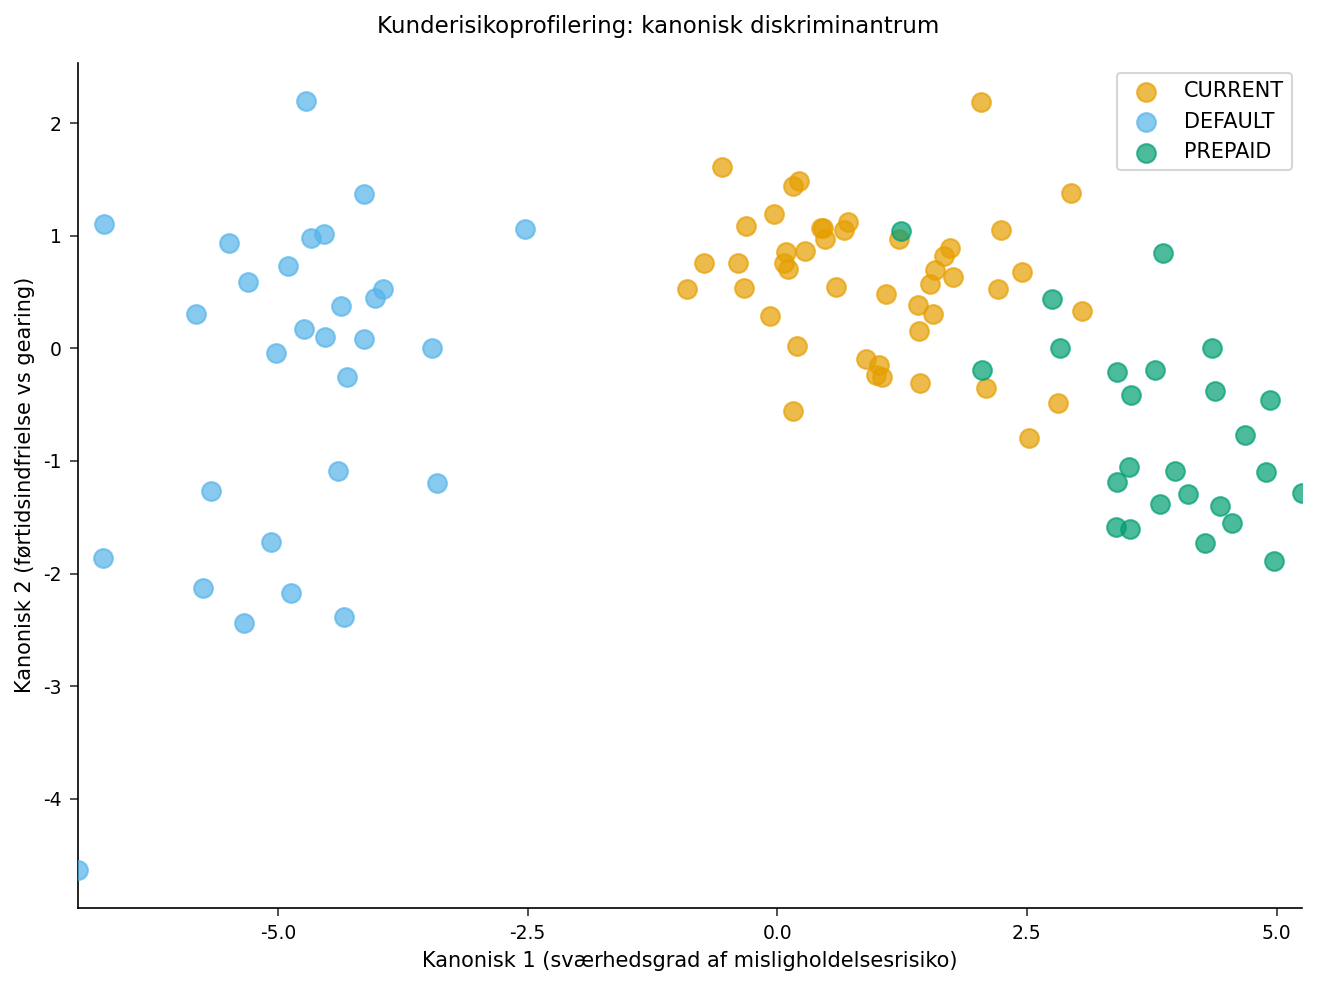

In [7]:
PROCEDURE SGPLOT data=work.risk_scores;
    SCATTER x=Can1 y=Can2 / GROUP=loan_status
        MARKERATTRS=(SYMBOL=circlefilled size=9)
        TRANSPARENCY=0.3;
    XAXIS MÆRKAT='Kanonisk 1 (sværhedsgrad af misligholdelsesrisiko)';
    YAXIS MÆRKAT='Kanonisk 2 (førtidsindfrielse vs gearing)';
    TITEL 'Kunderisikoprofilering: kanonisk diskriminantrum';
KØR;

---

### Fortolkning

De to kanoniske dimensioner adskiller de tre lånestatusgrupper skarpt inden for denne stikprøve på 100 kunder (46 løbende, 29 misligholdte, 25 førtidsindfriede).

**Dimension 1 — sværhedsgrad af misligholdelsesrisiko (kanonisk korrelation 0.958, 91.8% delt varians).** Denne akse alene tegner sig for det overvældende flertal af gruppeadskillelsen (egenværdi 11.20 mod 0.34 for den anden akse). I den samlede kanoniske struktur inden for klasserne lader den stærkest på kreditudnyttelse (-0.595), gæld-til-indkomst (-0.404), LTV (-0.370), måneder i restance (-0.324) og betaling-til-indkomst (-0.304) — hvert gearings- og byrdemål peger samme vej. Fordi loadingsene er negative, markerer lave (mere negative) Can1-scorer låntagerne med den højeste risiko. Klassecentroiderne bekræfter dette: misligholdte konti ligger ved Can1 = -4.83, løbende konti ved +0.96 og førtidsindfriede konti ved +3.84, en ren monoton ordning fra dårligst til bedst kreditsundhed.

**Dimension 2 — gearing kontra restance (kanonisk korrelation 0.503).** Den anden akse stiller LTV-forhold (+0.733) op mod måneder i restance (-0.700): den adskiller låntagere, der er højt gearede, men løbende, fra dem, der bærer restance. Den forfiner billedet inden for Can1, men bidrager med langt mindre adskillelse, som de næsten ens Can2-centroider for de præsterende grupper (løbende +0.599, førtidsindfriet -0.736) viser.

**Gruppeadskillelse.** De kvadrerede Mahalanobis-afstande mellem klassegennemsnit kvantificerer forskellene: DEFAULT-til-PREPAID er den største med 75.3, DEFAULT-til-CURRENT er 34.3, og CURRENT-til-PREPAID er den mindste med 10.1. De to præsterende grupper er derfor tættere på hinanden, end nogen af dem er på den misligholdte gruppe, præcis som en långiver ville forvente.

**Praktisk anvendelse.** Den første kanoniske score opfører sig som et færdigt sammensat risikoindeks: den komprimerer seks korrelerede nøgletal til én veladskilt dimension, der ordner kunder fra højest til lavest misligholdelsesrisiko. Porteføljeteams kan segmentere på Can1-skæringspunkter, og Mahalanobis-afstandene giver et principielt grundlag for at tildele en ny ansøger til den nærmeste statusgruppe under scorekortkalibrering.

---

### Eksport til scoringsmotoren

Bevar de kanoniske scorer pr. kunde og datasættet med kanoniske statistikker (som bærer centroiderne og Mahalanobis-afstandene) til efterfølgende scorekortkalibrering.

In [8]:
/* --------------------------------------------------------
   Export canonical risk scores and canonical statistics
   -------------------------------------------------------- */
PROCEDURE EKSPORTERE data=work.risk_scores
    OUTFILE='customer_risk_canonical_scores.csv'
    DBMS=csv REPLACE;
KØR;

PROCEDURE EKSPORTERE data=work.can_stat
    OUTFILE='canonical_statistics.csv'
    DBMS=csv REPLACE;
KØR;


NOTE: PROC EXPORT data=work.risk_scores outfile=customer_risk_canonical_scores.csv

NOTE: Exported 100 rows to customer_risk_canonical_scores.csv.
NOTE: PROC EXPORT data=work.can_stat outfile=canonical_statistics.csv

NOTE: Exported 31 rows to canonical_statistics.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Fortroligt
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Drevet af <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>